In [1]:
import edes 
from edes.utils.plotting import plot, plot_ax, big_plt_font, plot_ax_errbar, plot_errbar
from edes.utils.plotting import plot_generated_timelines, generate_signal_timeline
from edes.utils.circuits import dBm_to_W, W_to_dBm
import numpy as np 
from tqdm import tqdm, trange 
import matplotlib.pyplot as plt 
import time
import pandas as pd
from edes.utils.file_handling import load_h5_data, load_latest_data, load_latest_filename, list_filenames
import re
big_plt_font()

In [112]:
data_dir = '/home/electron/data/experiment_06282026'
all_files = list_filenames(data_dir)

In [12]:
def value_extraction(key): 
    pattern = r"dBm(?P<dBm_val>[-+]?\d*\.\d+|\d+)_average(?P<average>\d+)_repetition(?P<repetition>\d+)_data"
    match = re.match(pattern, key)
    data = match.groupdict()
    
    # Convert extracted strings to their proper numerical types
    dBm_Valon = float(data['dBm_val'])
    average = int(data['average'])
    repetition = int(data['repetition'])
    return dBm_Valon, average, repetition

def convert_dict_to_dataframe(input_dict):
    # Regex pattern to capture the values and determine if it's data or time
    pattern = r"dBm(?P<dBm>[-+]?\d*\.\d+|\d+)_average(?P<avg>\d+)_repetition(?P<rep>\d+)_(?P<type>data|time)"
    
    # Dictionary to temporarily store grouped records
    grouped_records = {}
    
    for key, val_array in input_dict.items():
        match = re.match(pattern, key)
        if match:
            # print('here')
            metadata = match.groupdict()
            # Convert extracted strings to their proper types
            dBm_val = float(metadata['dBm'])
            avg_val = int(metadata['avg'])
            rep_val = int(metadata['rep'])
            data_type = metadata['type']  # This will be either 'data' or 'time'
            
            # Unique identifier for this specific combination
            combo_key = (dBm_val, avg_val, rep_val)
            
            # Initialize the row structure if we haven't seen this combination yet
            if combo_key not in grouped_records:
                grouped_records[combo_key] = {
                    'dBm': dBm_val,
                    'avg': avg_val,
                    'rep': rep_val,
                    'data': None,
                    'time': None
                }
            
            # Assign the numpy array to the correct column ('data' or 'time')
            grouped_records[combo_key][data_type] = val_array

    # Convert the dictionary values into a list of rows and create the DataFrame
    df = pd.DataFrame(list(grouped_records.values()))
    
    # Optional: Reorder columns explicitly to match your request
    # df = df[['dBm', 'avg', 'rep', 'data', 'time']]
    
    return df

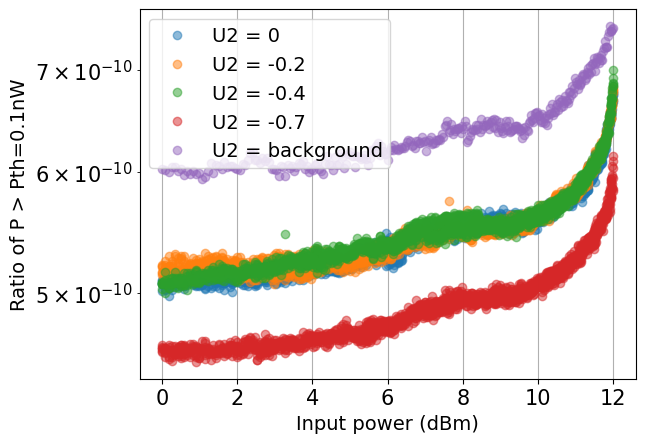

In [114]:
time_start = '10-00-00'
# all_meas, c, all_t = [], [], []
P_th = 0.1e-9
P_upper = 1
U2 = []
all_counts_sig = []
for file in all_files: 
    
    all_mean = [] 
    all_std = [] 
    all_min = [] 
    all_counts = []
    all_dBm = []
    all_sig_counts = 0 
    all_tot_counts = 0
    data_dict = load_h5_data('data/experiment_07092026/RFPowerConstSweepTipSwitched_14-11-46.h5', base=data_dir)
    if 'all_meas' in data_dict: 
        # print(file)
        continue
    # print(data_dict)
    df = convert_dict_to_dataframe(data_dict)
    # print(df)
    for i in range(len(df)): 
        idx = np.where(df['time'][i] < 3)
        # idx = np.where(df['time'][i] > 3)
        # idx = np.where((df['time'][i] > 4) & (df['time'][i] < 5))
        power0 = dBm_to_W(df['data'][i][idx])
        P_mean = np.mean(power0)
        Pth = P_mean + P_th
        power = power0[np.where((power0 >= Pth) & (power0 < P_upper))]
        all_dBm.append(df['dBm'][i]) 
        all_mean.append(np.mean(power0)) 
        all_std.append(np.std(power0)) 
        all_min.append(np.min(power0)) 
        all_counts.append(len(power)/len(power0))
        all_sig_counts += len(power) 
        all_tot_counts += len(power0)
    U2_test = 'background' if '13-34-18' in file else data_dict['U2']
    if U2_test == 0.5 or U2_test == -1: 
        continue
    if 1:#U2_test == -0.4:
        
        plot(all_dBm, all_mean, '.', xlabel='Input power (dBm)', ylabel=f'Ratio of P > Pth={P_th*1e9}nW', label=f"U2 = {U2_test}", alpha=0.5)
        # plot(all_dBm, all_mean, '.', xlabel='Input power (dBm)', ylabel=f'Ratio of P > Pth={P_th*1e9}nW', label=f"U2 = {data_dict['U2']}", alpha=0.5)
    plt.yscale('log')
    # plt.legend()
    # plt.ylim((plt.ylim()[0], 7.5e-5))
    U2.append(data_dict['U2'])
    all_counts_sig.append(all_sig_counts/all_tot_counts)
    # break

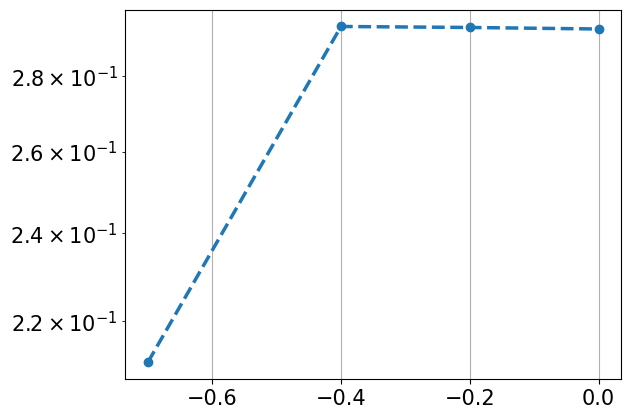

In [110]:
idx = np.argsort(U2)
plot(np.array(U2)[idx], np.array(all_counts_sig)[idx], '.--')
plt.yscale('log')

In [25]:
file['filename']

'/home/electron/data/experiment_06232026/RFPowerSweepAWG_10-24-48.h5'